In [490]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

import sys
import io
import datetime
import timeit
import os

pd.set_option('display.max_rows', 500)
pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 200)
pd.set_option('display.max_colwidth', 100)
#pd.set_option("display.precision", 2)
pd.set_option('display.float_format', lambda x: '%.2f' % x)

print('Python version ' + sys.version)
print('Pandas version ' + pd.__version__)
print('NumPy version ' + np.__version__)
print('matplotlib version ' + matplotlib.__version__)

timestamp = datetime.datetime.now().strftime('%Y-%m%d-%H%M')
print("Timestamp:", timestamp)
tstart = timeit.default_timer()

SERIES_COLORS = ['#2a78d6', '#eb6834', '#1baf7a', '#eda100']  # colorblind-safe, fixed order
INK, INK_MUTED, GRID = '#1f1f1e', '#6b6a64', '#e6e5df'

Python version 3.12.4 (v3.12.4:8e8a4baf65, Jun  6 2024, 17:33:18) [Clang 13.0.0 (clang-1300.0.29.30)]
Pandas version 3.0.5
NumPy version 2.5.2
matplotlib version 3.11.1
Timestamp: 2026-0926-2045


In [491]:
dir_path = "data/"
file_names = ["alumni.csv", "course_catalog.csv", "employment_history.csv", "student_experience.csv", "students_current.csv", "transcripts.csv"]

dfs = []
for file_name in file_names:
    dfs.append(pd.read_csv(os.path.join(dir_path, file_name), na_values="Not Applicable"))

df_alum, df_catalog, df_employ, df_studexp, df_studcurr, df_trans = dfs

In [492]:
for df in dfs:
    print(f"{df.info()}\n")

<class 'pandas.DataFrame'>
RangeIndex: 3200 entries, 0 to 3199
Data columns (total 29 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   campus_id                           3200 non-null   str    
 1   major                               3200 non-null   str    
 2   degree_level                        3200 non-null   str    
 3   track                               3200 non-null   str    
 4   graduation_term                     3200 non-null   str    
 5   graduation_year                     3200 non-null   int64  
 6   entry_type                          3200 non-null   str    
 7   time_to_degree_years                3200 non-null   float64
 8   total_credits_earned                3200 non-null   int64  
 9   final_gpa                           3200 non-null   float64
 10  major_gpa                           3200 non-null   float64
 11  residency                           3200 non-null   st

In [493]:
df_bigcurr = df_trans.merge(df_studcurr, on="campus_id", how="inner")
df_bigalum = df_trans.merge(df_alum, on="campus_id", how="inner")
col = ["first_job_annual_salary_usd", "months_to_first_job", "first_job_is_remote"]
pd.to_numeric(col, errors="coerce")

col = ["first_job_annual_salary_usd", "months_to_first_job", "first_job_is_remote"]
pd.to_numeric(col, errors="coerce")

array([nan, nan, nan])

In [494]:
print(f"Current Student Major Count: {df_studcurr['major'].value_counts()}\n")
print(f"Alumni Major Count: {df_alum['major'].value_counts()}\n")

Current Student Major Count: major
Computer Science       1105
Information Systems     695
Name: count, dtype: int64

Alumni Major Count: major
Computer Science       1982
Information Systems    1218
Name: count, dtype: int64



## What is our definition of the "success" of a student?

"Success" means something different to different people depending on their career and educational goals. We are using salary as our metric of success by measuring how different factors are correlated to median and average salaries, comparing datapoints with each other, and visualizing them to make the distinctions more clear. Each section will calculate a correlation coefficient and/or % representing the SHARE of the variation of the salary (i.e. how much each factor is affecting the variation). Note: Until the unemployment rate section, these charts and tables are calculated excluding alumni still seeking work

### Majors and their effect on "Success"

In [495]:
df_alumcareer = df_employ.merge(df_alum, on='campus_id', how='inner') # joining employ with alum table on campus_id: shows the career path of alum

aggregations = {'max_salary' : ('annual_salary_usd', 'max'), 
                'avg_salary' : ('annual_salary_usd', 'mean'),
                'job_count' : ('job_id', 'count')}

aggregations2 = {'job_count_avg': ('job_count', 'mean'),
                 'avg_salary': ('avg_salary', 'mean'),
                 'max_salary': ('max_salary', 'max'),
                 'alum_count': ('campus_id', 'count')}

df_alumcareerinfo = df_alumcareer.groupby(['campus_id', 'major', 'degree_level']).agg(**aggregations).reset_index().sort_values('avg_salary', ascending=False)
df_majorcareerinfo = df_alumcareerinfo.groupby(['major', 'degree_level']).agg(**aggregations2).reset_index()
df_majorcareerinfo

,major,degree_level,job_count_avg,avg_salary,max_salary,alum_count
0,Computer Science,Bachelor of Science,2.88,87580.55,205500,1252
1,Computer Science,Master of Science,2.86,90547.98,157000,69
2,Information Systems,Bachelor of Science,2.70,85849.91,220500,780
3,Information Systems,Master of Science,2.48,82232.96,165500,46


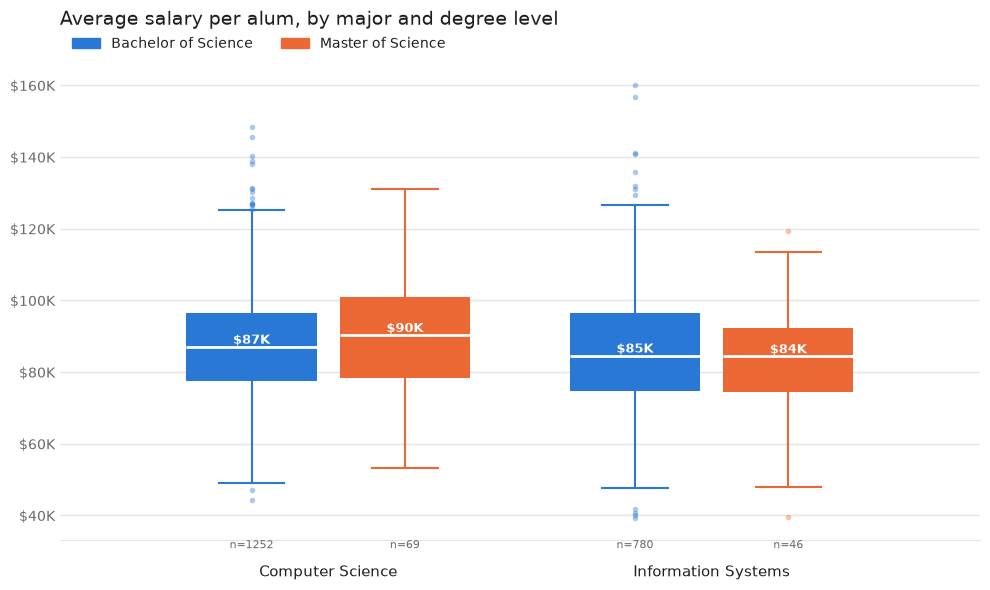

In [496]:
from matplotlib.ticker import FuncFormatter

majors  = sorted(df_alumcareerinfo['major'].unique())
degrees = sorted(df_alumcareerinfo['degree_level'].unique())
colors  = dict(zip(degrees, SERIES_COLORS))

fig, ax = plt.subplots(figsize=(10, 6))
width = 0.8 / len(degrees)

for i, degree in enumerate(degrees):
    # offset each degree's box within its major group
    positions = [m + (i - (len(degrees) - 1) / 2) * width for m in range(len(majors))]
    data = [df_alumcareerinfo.loc[(df_alumcareerinfo['major'] == m) &
                                  (df_alumcareerinfo['degree_level'] == degree), 'avg_salary']
            for m in majors]
    bp = ax.boxplot(data, positions=positions, widths=width * 0.85, patch_artist=True,
                    medianprops=dict(color='white', linewidth=2),
                    boxprops=dict(linewidth=0),
                    whiskerprops=dict(color=colors[degree], linewidth=1.5),
                    capprops=dict(color=colors[degree], linewidth=1.5),
                    flierprops=dict(marker='o', markersize=4, alpha=0.4,
                                    markerfacecolor=colors[degree], markeredgecolor='none'))
    for box in bp['boxes']:
        box.set_facecolor(colors[degree])

    # label the median and sample size for each box
    for pos, d in zip(positions, data):
        if len(d):
            ax.text(pos, d.median(), f"${d.median()/1000:.0f}K", ha='center', va='bottom',
                    fontsize=9, color='white', fontweight='bold')
        ax.text(pos, 0, f"n={len(d)}", ha='center', va='top', fontsize=8, color=INK_MUTED,
                transform=ax.get_xaxis_transform())

ax.set_xticks(range(len(majors)), majors, fontsize=11, color=INK)
ax.tick_params(axis='x', length=0, pad=18)
ax.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"${v/1000:.0f}K"))
ax.tick_params(axis='y', colors=INK_MUTED, length=0)
ax.grid(axis='y', color=GRID, linewidth=1)
ax.set_axisbelow(True)
for side in ['top', 'right', 'left']:
    ax.spines[side].set_visible(False)
ax.spines['bottom'].set_color(GRID)

ax.set_title('Average salary per alum, by major and degree level', loc='left',
             fontsize=14, color=INK, pad=28)
ax.legend(handles=[plt.Rectangle((0, 0), 1, 1, color=colors[d]) for d in degrees],
          labels=degrees, loc='lower left', bbox_to_anchor=(0, 1.0), ncol=len(degrees),
          frameon=False, fontsize=10, labelcolor=INK)

plt.tight_layout()
plt.show()


Most alumni in the dataset only hold a bachelor's degree (2,032 vs 115 with a master's), so the master's comparisons are built on small samples. Among the alumni, the typical salary gap between COmputer Science and Information Systems is small: CS alumni earn a median of about 3% more, and the two distributions overlap almost entirely. Although Information Systems is often viewed as the weaker major, the data shows that both lead to very similar salries.

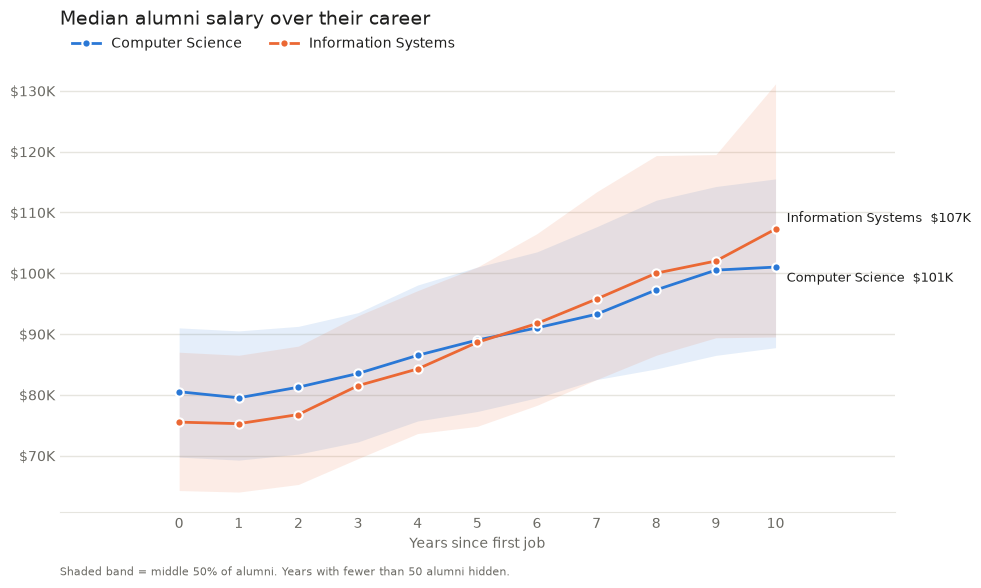

In [497]:
MIN_N = 50   # hide years with too few alumni to trust the median

# salary each alum was earning at each full year since their first job started
career = df_alumcareer.copy()
career['start_date'] = pd.to_datetime(career['start_date'])
career['end_date'] = pd.to_datetime(career['end_date']).fillna(pd.Timestamp.today())  # current jobs
first_start = career.groupby('campus_id')['start_date'].transform('min')
career['start_yr'] = (career['start_date'] - first_start).dt.days / 365.25
career['end_yr'] = (career['end_date'] - first_start).dt.days / 365.25

rows = []
for (cid, major), jobs in career.sort_values('start_date').groupby(['campus_id', 'major']):
    for year in range(int(jobs['end_yr'].max()) + 1):
        held = jobs[jobs['start_yr'] <= year]            # jobs started by this point
        rows.append((cid, major, year, held['annual_salary_usd'].iloc[-1]))
by_alum_year = pd.DataFrame(rows, columns=['campus_id', 'major', 'years_in', 'annual_salary_usd'])

trend = (by_alum_year.groupby(['major', 'years_in'])['annual_salary_usd']
                     .agg(median='median', p25=lambda s: s.quantile(.25),
                          p75=lambda s: s.quantile(.75), n='count')
                     .reset_index())
trend = trend[trend['n'] >= MIN_N]

majors = sorted(trend['major'].unique())
colors = dict(zip(majors, SERIES_COLORS))

fig, ax = plt.subplots(figsize=(10, 6))
for major in majors:
    t = trend[trend['major'] == major]
    ax.fill_between(t['years_in'], t['p25'], t['p75'], color=colors[major], alpha=0.12, linewidth=0)
    ax.plot(t['years_in'], t['median'], color=colors[major], linewidth=2,
            marker='o', markersize=6, markeredgecolor='white', markeredgewidth=1.5, label=major)

# direct-label each line's end; nudge labels apart so they don't collide
ends = trend.loc[trend.groupby('major')['years_in'].idxmax()].sort_values('median')
for i, (_, row) in enumerate(ends.iterrows()):
    ax.annotate(f"{row['major']}  ${row['median']/1000:.0f}K", (row['years_in'], row['median']),
                xytext=(8, (i - (len(ends) - 1) / 2) * 16), textcoords='offset points',
                va='center', fontsize=9, color=INK)

ax.set_xlabel('Years since first job', color=INK_MUTED)
ax.set_xticks(sorted(trend['years_in'].unique()))
ax.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"${v/1000:.0f}K"))
ax.tick_params(colors=INK_MUTED, length=0)
ax.grid(axis='y', color=GRID, linewidth=1)
ax.set_axisbelow(True)
for side in ['top', 'right', 'left']:
    ax.spines[side].set_visible(False)
ax.spines['bottom'].set_color(GRID)
ax.margins(x=0.2)

ax.set_title('Median alumni salary over their career', loc='left', fontsize=14, color=INK, pad=28)
ax.legend(loc='lower left', bbox_to_anchor=(0, 1.0), ncol=len(majors), frameon=False,
          fontsize=10, labelcolor=INK)
ax.text(0, -0.14, f"Shaded band = middle 50% of alumni. Years with fewer than {MIN_N} alumni hidden.",
        transform=ax.transAxes, fontsize=8, color=INK_MUTED)

plt.tight_layout()
plt.show()


This idea of similar salaries is further shown in the above chart, where the median salary of alumni is plotted over time and compared to each other. This chart shows that IS majors close an observed initial gap by around the 5 year mark, and since there are less alumni in later years beyond the 8 year mark, the gap at the end of the chart gives a less certain conclusion of the IS major lead in salary, especially since the minimum alumni for a year is 50 (as set by me).

In [498]:
df_corr = df_alum.copy()
df_corr['first_job_annual_salary_usd'] = pd.to_numeric(df_corr['first_job_annual_salary_usd'], errors='coerce')
df_corr = df_corr.dropna(subset=['first_job_annual_salary_usd'])
df_corr['is_info_systems'] = (df_corr['major'] == 'Information Systems').astype(int)

df_corr['is_info_systems'].corr(df_corr['first_job_annual_salary_usd'])

np.float64(-0.13530589801718018)

A correlation coefficient of ~-0.135 (IS coded as 1) tells us that major and salary are WEAKLY correlated since it's closer to 0, but not negligible. Squaring it to get 0.018 shows that only about 2% of the variation in starting salary is explained by the major. The negative value refers to the fact that IS alumni start slightly lower on average, but the two distributions overlap almost entirely.

### Internships and their effect on "Success"

In [499]:
df_intern = df_alum.copy()
for c in ['first_job_annual_salary_usd', 'months_to_first_job']:
    df_intern[c] = pd.to_numeric(df_intern[c], errors='coerce')   # 'Not Applicable' -> NaN
df_intern['employed_full_time'] = df_intern['first_destination'] == 'Employed Full-Time'
df_intern['return_offer'] = df_intern['first_job_found_via'] == 'Return Offer from Internship'

by_intern = (df_intern.groupby('internship_count')
             .agg(alum_count=('campus_id', 'count'),
                  median_salary=('first_job_annual_salary_usd', 'median'),
                  median_months=('months_to_first_job', 'median'),
                  pct_full_time=('employed_full_time', 'mean'),
                  pct_return_offer=('return_offer', 'mean'))
             .reset_index())
by_intern


,internship_count,alum_count,median_salary,median_months,pct_full_time,pct_return_offer
0,0,773,67750.00,4.20,0.58,0.00
1,1,1368,78750.00,0.90,0.62,0.17
2,2,837,83750.00,0.30,0.68,0.34
3,3,212,87500.00,0.30,0.65,0.47
4,4,10,70500.00,0.25,0.60,0.40


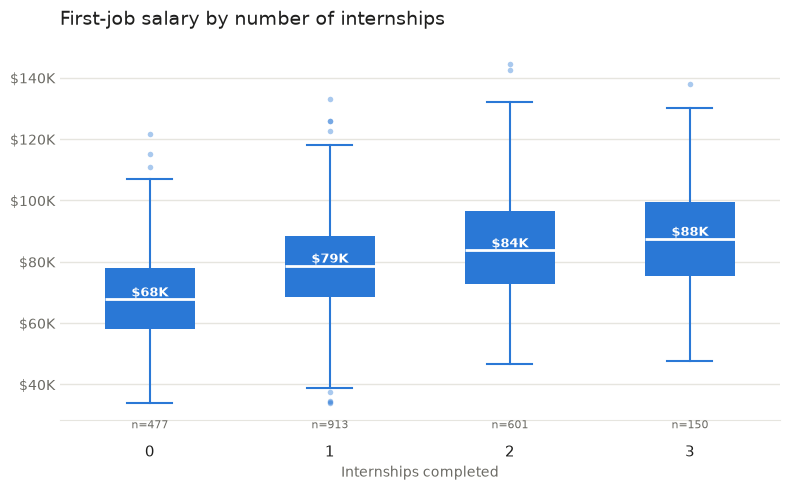

In [500]:
counts = [c for c in sorted(df_intern['internship_count'].unique())
          if (df_intern['internship_count'] == c).sum() >= MIN_N]
data = [df_intern.loc[df_intern['internship_count'] == c, 'first_job_annual_salary_usd'].dropna() for c in counts]

fig, ax = plt.subplots(figsize=(8, 5))
bp = ax.boxplot(data, positions=range(len(counts)), widths=0.5, patch_artist=True,
                medianprops=dict(color='white', linewidth=2), boxprops=dict(linewidth=0),
                whiskerprops=dict(color=SERIES_COLORS[0], linewidth=1.5),
                capprops=dict(color=SERIES_COLORS[0], linewidth=1.5),
                flierprops=dict(marker='o', markersize=4, alpha=0.4,
                                markerfacecolor=SERIES_COLORS[0], markeredgecolor='none'))
for box in bp['boxes']:
    box.set_facecolor(SERIES_COLORS[0])
for pos, d in enumerate(data):
    ax.text(pos, d.median(), f"${d.median()/1000:.0f}K", ha='center', va='bottom',
            fontsize=9, color='white', fontweight='bold')
    ax.text(pos, 0, f"n={len(d)}", ha='center', va='top', fontsize=8, color=INK_MUTED,
            transform=ax.get_xaxis_transform())

ax.set_xticks(range(len(counts)), counts, fontsize=11, color=INK)
ax.tick_params(axis='x', length=0, pad=18)
ax.set_xlabel('Internships completed', color=INK_MUTED)
ax.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"${v/1000:.0f}K"))
ax.tick_params(axis='y', colors=INK_MUTED, length=0)
ax.grid(axis='y', color=GRID, linewidth=1)
ax.set_axisbelow(True)
for side in ['top', 'right', 'left']:
    ax.spines[side].set_visible(False)
ax.spines['bottom'].set_color(GRID)
ax.set_title('First-job salary by number of internships', loc='left', fontsize=14, color=INK, pad=16)
plt.tight_layout()
plt.show()


The box chart suggests that there is a large difference between the starting salaries of alum who completed 0 internships and alum who completed 3 internships. However, there is a lot of overlap between the distributions of 2 internships and 3 internships, which suggests that the potential of a higher salary levels off at 2 and 3 internships.

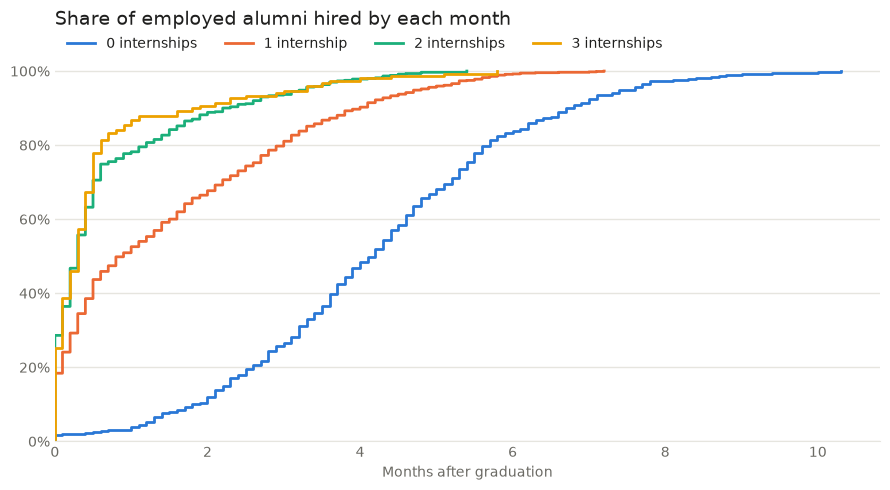

In [501]:
fig, ax = plt.subplots(figsize=(9, 5))
for i, c in enumerate(counts):
    months = np.sort(df_intern.loc[df_intern['internship_count'] == c, 'months_to_first_job'].dropna())
    pct_hired = np.arange(1, len(months) + 1) / len(months)
    ax.step(months, pct_hired, where='post', color=SERIES_COLORS[i], linewidth=2)

ax.set_xlabel('Months after graduation', color=INK_MUTED)
ax.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:.0%}"))
ax.tick_params(colors=INK_MUTED, length=0)
ax.grid(axis='y', color=GRID, linewidth=1)
ax.set_axisbelow(True)
for side in ['top', 'right', 'left']:
    ax.spines[side].set_visible(False)
ax.spines['bottom'].set_color(GRID)
ax.set_xlim(0, None)
ax.set_ylim(0, 1.02)
ax.set_title('Share of employed alumni hired by each month', loc='left', fontsize=14, color=INK, pad=28)
ax.legend([f"{c} internship{'s' if c != 1 else ''}" for c in counts], loc='lower left',
          bbox_to_anchor=(0, 1.0), ncol=len(counts), frameon=False, fontsize=10, labelcolor=INK)
plt.tight_layout()
plt.show()

The overlap in the salary chart is reflected in a similar pattern by the above chart that shows the hiring speed. Most employed alumni with 2 or 3 internships were hired within a month of graduation while those with 0 or 1 internships took a lot longer. This suggests that the 3rd internship is adding little value to both the salary and hire time as compared to a 2nd internship.

In [502]:
had_intern = df_intern[(df_intern['internship_count'] > 0) & df_intern['first_job_annual_salary_usd'].notna()]

offer_table = (had_intern.pivot_table(index='internship_count', columns='return_offer',
                                      values='first_job_annual_salary_usd', aggfunc=['median', 'count'])
               .rename(columns={False: 'no_offer', True: 'offer'}))
offer_table.columns = [f'{stat}_{grp}' for stat, grp in offer_table.columns]   # flatten the 2-level header
offer_table['offer_premium'] = offer_table['median_offer'] - offer_table['median_no_offer']
offer_table = offer_table[offer_table['count_offer'] >= 10].reset_index()   # 4 internships has only 4 offers
offer_table

,internship_count,median_no_offer,median_offer,count_no_offer,count_offer,offer_premium
0,1,77500.00,82750.00,682,231,5250.00
1,2,81000.00,87750.00,319,282,6750.00
2,3,83500.00,90250.00,51,99,6750.00


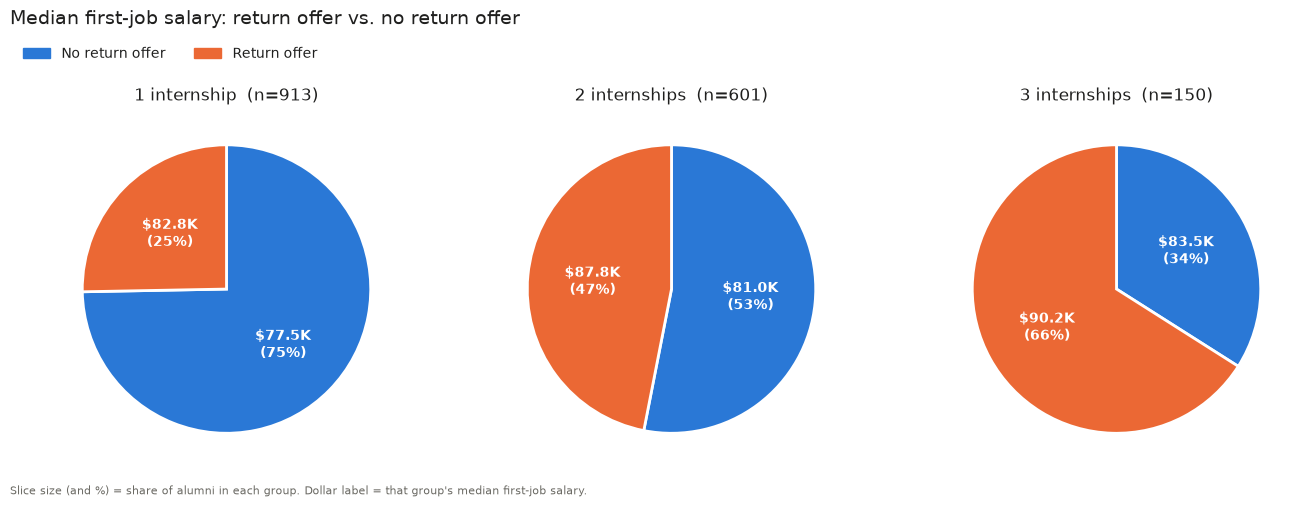

In [503]:
groups = [('no_offer', 'No return offer', SERIES_COLORS[0]),
          ('offer', 'Return offer', SERIES_COLORS[1])]

fig, axes = plt.subplots(1, len(offer_table), figsize=(4.5 * len(offer_table), 5))
for ax, (_, row) in zip(axes, offer_table.iterrows()):
    counts = [int(row[f'count_{g}']) for g, _, _ in groups]
    wedges, _ = ax.pie(counts, colors=[c for _, _, c in groups], startangle=90, counterclock=False,
                       wedgeprops=dict(edgecolor='white', linewidth=2))
    total = sum(counts)

    # place each label at the middle of its slice, 55% of the way out from the center
    for wedge, (g, _, _), n in zip(wedges, groups, counts):
        angle = np.deg2rad((wedge.theta1 + wedge.theta2) / 2)
        x, y = 0.55 * np.cos(angle), 0.55 * np.sin(angle)
        ax.text(x, y, f"${row[f'median_{g}']/1000:.1f}K\n({n / total:.0%})",
                ha='center', va='center', fontsize=10, color='white', fontweight='bold')

    n_int = int(row['internship_count'])
    ax.set_title(f"{n_int} internship{'s' if n_int != 1 else ''}  (n={total})", fontsize=12, color=INK)

fig.suptitle('Median first-job salary: return offer vs. no return offer', x=0.01, ha='left',
             fontsize=14, color=INK)
fig.legend(handles=[plt.Rectangle((0, 0), 1, 1, color=c) for _, _, c in groups],
           labels=[label for _, label, _ in groups], loc='upper left', bbox_to_anchor=(0.01, 0.93),
           ncol=2, frameon=False, fontsize=10, labelcolor=INK)
fig.text(0.01, 0.01, "Slice size (and %) = share of alumni in each group. Dollar label = that group's median first-job salary.",
         fontsize=8, color=INK_MUTED)
plt.tight_layout(rect=(0, 0.03, 1, 0.88))
plt.show()


These pie charts compare alumni whose first job was a return offer from an internship to those who found their first job some other way. At every internship count, alumni with a return offer earned a higher median starting salary: +$5,250 with 1 internship, and +$6,750 with 2 or 3 internships. Return offers also become much more common as internships go up: about 25% of alumni with 1 internship got one, compared to 47% with 2 and 66% with 3. This suggests that part of the value of doing more internships is a better chance of converting one into a higher-paying full-time offer. (4 internships is left out since only 4 alumni in that group received a return offer.)

### First Family Job and Industry Effects of "Success"

In [504]:
jobs = df_employ.assign(start_date=pd.to_datetime(df_employ['start_date'])).sort_values('start_date')
career = jobs.groupby('campus_id').agg(
    first_family=('job_family', 'first'),
    first_industry=('employer_industry', 'first'),
    first_salary=('annual_salary_usd', 'first'),
    latest_salary=('annual_salary_usd', 'last'),
    first_start=('start_date', 'first'),
    last_start=('start_date', 'last'),
    last_tenure=('tenure_months', 'last'))
career['years_experience'] = ((career['last_start'] - career['first_start']).dt.days / 365.25
                              + career['last_tenure'] / 12)

# how far above/below a typical alum with the same years of experience each alum earns now
slope, intercept = np.polyfit(career['years_experience'], career['latest_salary'], 1)
career['salary_vs_peers'] = career['latest_salary'] - (intercept + slope * career['years_experience'])

def summarize(col):
    return (career.groupby(col)
            .agg(alum_count=('first_salary', 'count'),
                 median_first_salary=('first_salary', 'median'),
                 median_vs_peers=('salary_vs_peers', 'median'))
            .query('alum_count >= @MIN_N')
            .sort_values('median_first_salary', ascending=False))

family_summary = summarize('first_family')
industry_summary = summarize('first_industry')
family_summary


,alum_count,median_first_salary,median_vs_peers
first_family,,,
Cybersecurity,342,91250.00,11586.98
Infrastructure & Cloud,234,84750.00,6028.77
Machine Learning & AI,177,83500.00,1779.90
IT Business & Product,274,75750.00,443.28
Software Engineering,481,75250.00,-5117.65
Health IT,109,75000.00,-4168.92
Data & Analytics,425,72250.00,-8999.50
IT Support & Operations,105,63000.00,-22957.95


This table shows the median first salary of each job family. One thing to note is that no alumni switched job families OR industries. Based on the results, the median salary is MUCH higher with Cybersecurity and Infrastructure & Cloud compared to peers with the same amount of experience (in years). It also shows that alumni who pursued IT Support & Operations ended up having a much smaller salary compared to their peers with the same amount of experience. This strongly suggests, with the large distribution of alum across the families, that the first job family an alum works in affects the salary significantly.

In [505]:
industry_summary

,alum_count,median_first_salary,median_vs_peers
first_industry,,,
Cloud & Infrastructure,122,90500.00,9026.28
Cybersecurity Services,65,85250.00,544.24
Software Products,219,85250.00,2755.73
Financial Services,103,84500.00,4957.11
E-Commerce & Retail Tech,125,81250.00,637.81
Consulting & Professional Services,120,80875.00,2883.28
Telecommunications,53,80500.00,8688.50
Defense & Aerospace,233,79500.00,623.64
Federal Contracting,482,78000.00,-3183.81


Similarly, this table shows the median first salary of each job industry. The median salaries for Cloud & Infrastructure as well as Telecommunications are much higher than Federal Government compared to peers. Interestingly enough, the industry and job family tables both share Cloud & Infrastructure as rows, and they both yield comparitively higher median salaries. Like the job family table, this table also demonstrates a significance of the first job industry an alum works in on the salary.

In [506]:
def eta_squared(df, group_col, value_col):
    # share of the variance in value_col explained by which group each alum is in
    grand_mean = df[value_col].mean()
    between = df.groupby(group_col)[value_col].agg(lambda s: len(s) * (s.mean() - grand_mean) ** 2).sum()
    return between / ((df[value_col] - grand_mean) ** 2).sum()

career_major = career.join(df_alum.set_index('campus_id')['major'])
pd.DataFrame({outcome: {grp: eta_squared(career_major, grp, outcome)
                        for grp in ['major', 'first_family', 'first_industry']}
              for outcome in ['first_salary', 'salary_vs_peers']})


,first_salary,salary_vs_peers
major,0.02,0.00
first_family,0.20,0.20
first_industry,0.16,0.10


This table uses the ANOVA Test to check how correlated each factor is to the salary: major, first job family, and first industry. As discussed before, the major only has about a 2% share of the variance which is supported by the table. The first job family has 20% and the first industry has 16%, which shows that both of these have a major effect on the salary compared to their peers with the same level of experience.

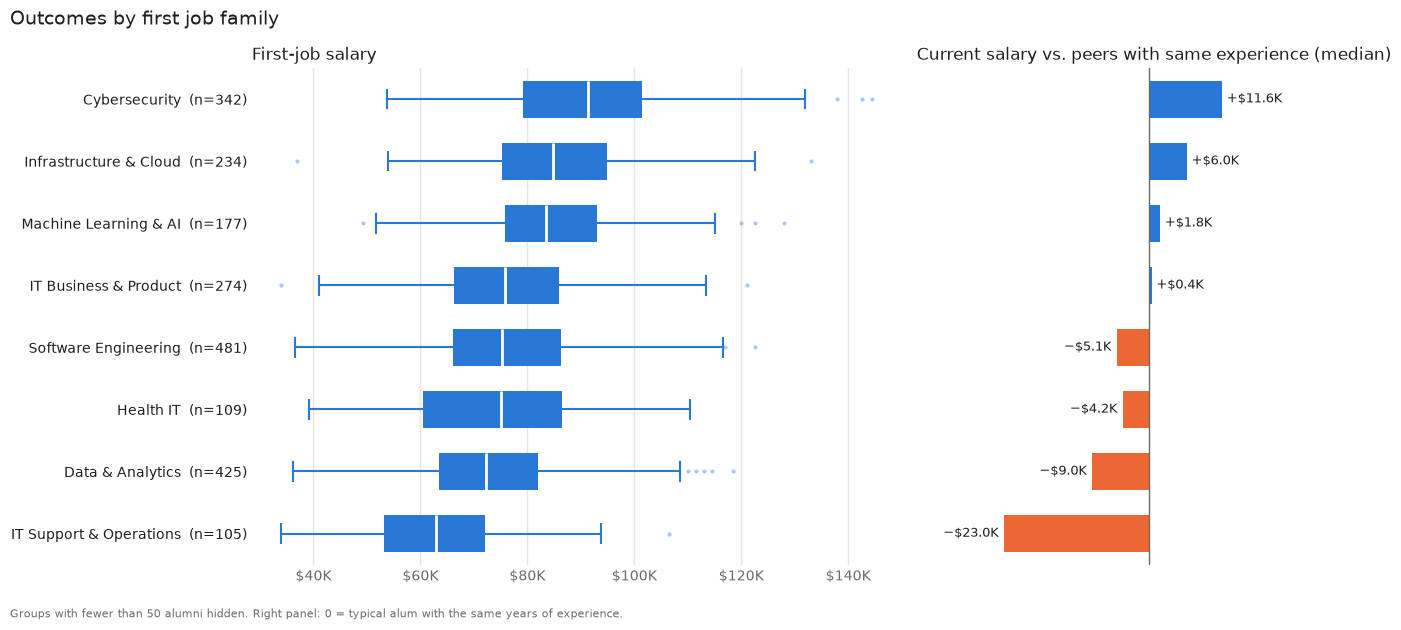

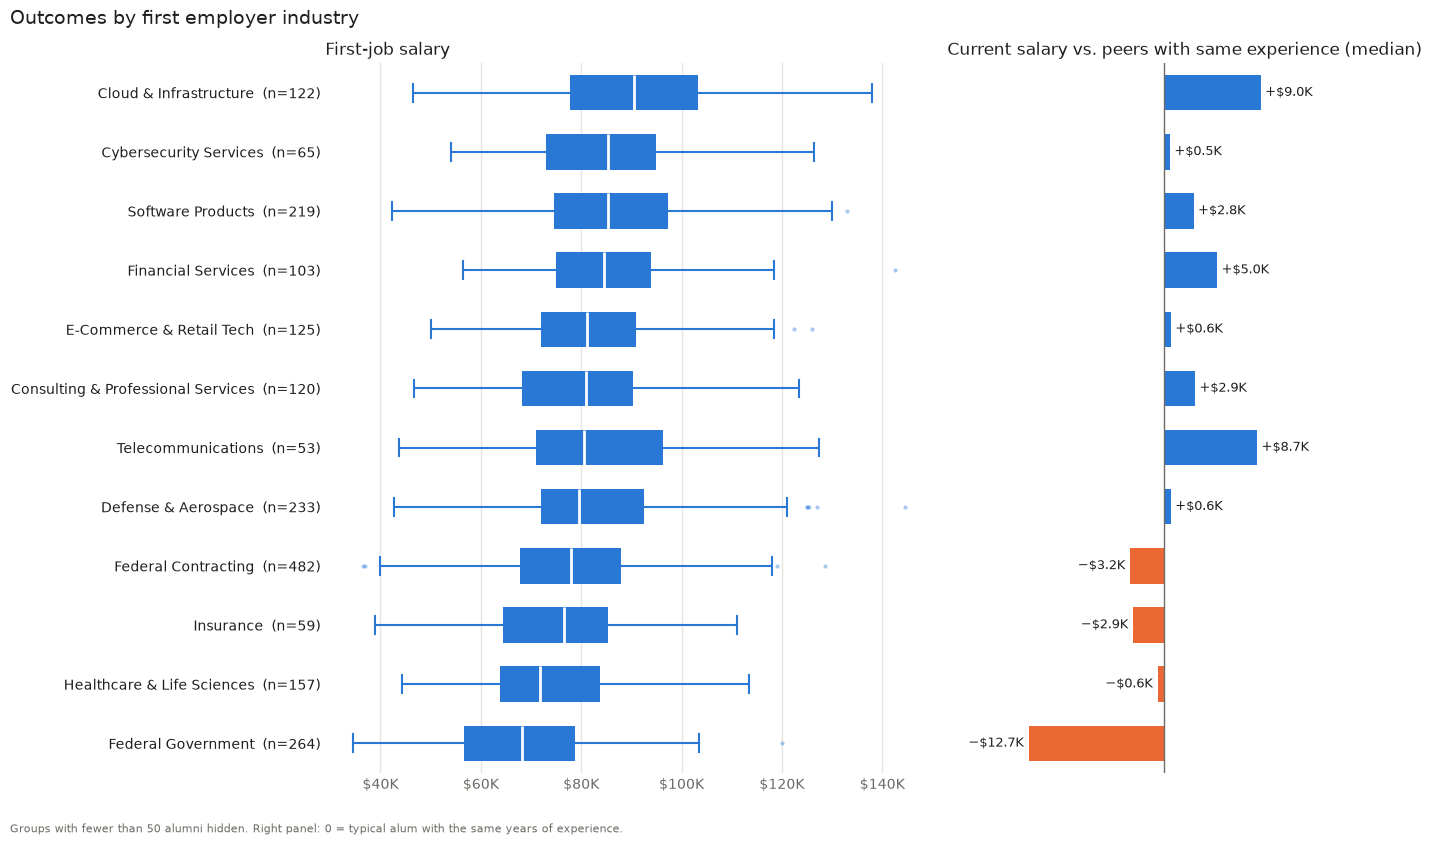

In [507]:
def plot_first_job(summary, col, title):
    order = summary.index[::-1]   # highest starting salary at the top
    data = [career.loc[career[col] == g, 'first_salary'] for g in order]
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 0.55 * len(order) + 1.8), sharey=True,
                                   gridspec_kw={'width_ratios': [1.4, 1]})

    bp = ax1.boxplot(data, positions=range(len(order)), orientation='horizontal', widths=0.6, patch_artist=True,
                     medianprops=dict(color='white', linewidth=2), boxprops=dict(linewidth=0),
                     whiskerprops=dict(color=SERIES_COLORS[0], linewidth=1.5),
                     capprops=dict(color=SERIES_COLORS[0], linewidth=1.5),
                     flierprops=dict(marker='o', markersize=3, alpha=0.4,
                                     markerfacecolor=SERIES_COLORS[0], markeredgecolor='none'))
    for box in bp['boxes']:
        box.set_facecolor(SERIES_COLORS[0])
    ax1.set_yticks(range(len(order)), [f"{g}  (n={summary.loc[g, 'alum_count']})" for g in order])
    ax1.xaxis.set_major_formatter(FuncFormatter(lambda v, _: f"${v/1000:.0f}K"))
    ax1.grid(axis='x', color=GRID, linewidth=1)
    ax1.set_title('First-job salary', loc='left', fontsize=12, color=INK)

    vals = summary.loc[order, 'median_vs_peers']
    ax2.barh(range(len(order)), vals, height=0.6,
             color=[SERIES_COLORS[0] if v >= 0 else SERIES_COLORS[1] for v in vals])
    lim = vals.abs().max() * 1.6
    for i, v in enumerate(vals):
        ax2.text(v + lim * 0.02 * (1 if v >= 0 else -1), i, f"{'+' if v >= 0 else '−'}${abs(v)/1000:.1f}K",
                 va='center', ha='left' if v >= 0 else 'right', fontsize=9, color=INK)
    ax2.axvline(0, color=INK_MUTED, linewidth=1)
    ax2.set_xlim(-lim, lim)
    ax2.set_xticks([])
    ax2.set_title('Current salary vs. peers with same experience (median)', loc='left', fontsize=12, color=INK)

    for ax in (ax1, ax2):
        ax.set_axisbelow(True)
        ax.tick_params(colors=INK, length=0)
        ax.tick_params(axis='x', colors=INK_MUTED)
        for side in ['top', 'right', 'left', 'bottom']:
            ax.spines[side].set_visible(False)

    fig.suptitle(title, x=0.01, ha='left', fontsize=14, color=INK)
    fig.text(0.01, 0.0, f"Groups with fewer than {MIN_N} alumni hidden. Right panel: 0 = typical alum with the same years of experience.",
             fontsize=8, color=INK_MUTED)
    plt.tight_layout(rect=(0, 0.03, 1, 1))
    plt.show()

plot_first_job(family_summary, 'first_family', 'Outcomes by first job family')
plot_first_job(industry_summary, 'first_industry', 'Outcomes by first employer industry')


These charts visually represents what was just discussed in the previous point. The first job family and first industry both have a large variance in salary, especially for IT Support & Operations : Cybersecurity and Federal Government : Cloud & Infrastructure.

### Unemployment Rates

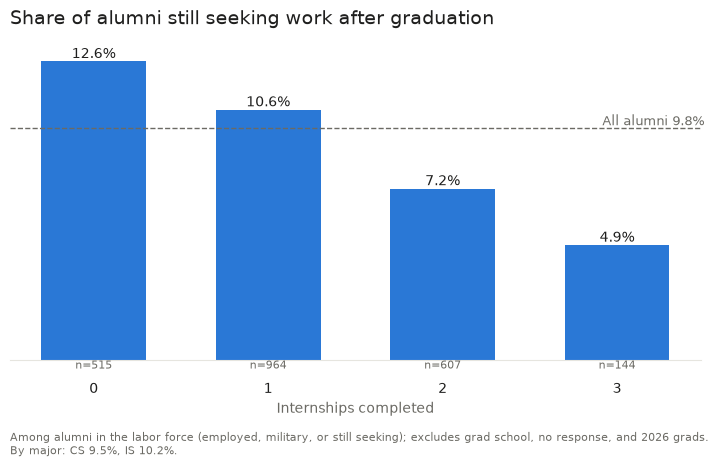

In [508]:
in_labor_force = ['Employed Full-Time', 'Employed Part-Time', 'Military', 'Still Seeking']
df_lf = df_alum[df_alum['first_destination'].isin(in_labor_force)
                & (df_alum['graduation_year'] < 2026)].copy()     # 2026 grads haven't had time to search
df_lf['unemployed'] = df_lf['first_destination'] == 'Still Seeking'

unemp = (df_lf.groupby('internship_count')['unemployed']
              .agg(rate='mean', alum_count='size')
              .query('alum_count >= @MIN_N'))
overall_rate = df_lf['unemployed'].mean()
by_major = df_lf.groupby('major')['unemployed'].mean()

fig, ax = plt.subplots(figsize=(8, 5))
x = unemp.index.astype(str)
ax.bar(x, unemp['rate'], color=SERIES_COLORS[0], width=0.6)
for xi, r, n in zip(x, unemp['rate'], unemp['alum_count']):
    ax.text(xi, r, f"{r:.1%}", ha='center', va='bottom', fontsize=10, color=INK)
    ax.text(xi, 0, f"n={n}", ha='center', va='top', fontsize=8, color=INK_MUTED,
            transform=ax.get_xaxis_transform())
ax.axhline(overall_rate, color=INK_MUTED, linewidth=1, linestyle='--')
ax.text(len(x) - 0.5, overall_rate, f"All alumni {overall_rate:.1%}", ha='right', va='bottom',
        fontsize=9, color=INK_MUTED)

ax.set_xlabel('Internships completed', color=INK_MUTED)
ax.tick_params(axis='x', colors=INK, length=0, pad=16)
ax.set_yticks([])
for side in ['top', 'right', 'left']:
    ax.spines[side].set_visible(False)
ax.spines['bottom'].set_color(GRID)
ax.set_title('Share of alumni still seeking work after graduation', loc='left', fontsize=14, color=INK, pad=16)
ax.text(0, -0.3, "Among alumni in the labor force (employed, military, or still seeking); excludes grad school, "
                 f"no response, and 2026 grads.\nBy major: CS {by_major['Computer Science']:.1%}, "
                 f"IS {by_major['Information Systems']:.1%}.",
        transform=ax.transAxes, fontsize=8, color=INK_MUTED)
plt.tight_layout()
plt.show()

Unlike the previous sections, this chart includes alumni still seeking work. Only alumni in the labor force (employed, military, or still seeking) are counted, and 2026 graduates are left out since they haven't had time to search yet. Overall, 9.8% of alumni were still seeking work after graduation, and major makes almost no difference (CS 9.5% vs IS 10.2%). Internships make a much bigger difference: the unemployment rate drops steadily from 12.6% with 0 internships to 10.6% with 1, 7.2% with 2, and 4.9% with 3. Unlike salary and hiring speed, which leveled off after 2 internships, the unemployment rate keeps dropping with a 3rd internship, although the 3-internship group is smaller (n=144).

### Student Activities

In [509]:
aggregations = {'records' : ('record_id', 'count'),
  'students' : ("campus_id", "nunique"),
  'orgs' : ("organization", "nunique"),
  'avg_terms' : ("duration_terms", "mean"),
  'avg_hours' : ("hours_per_week", "mean"),
  'pct_paid' : ("is_paid", lambda s: s.dropna().astype(bool).mean() * 100)}

exp_by_type = df_studexp.groupby("experience_type").agg(**aggregations).round(1).sort_values("records", ascending=False)
exp_by_type.fillna('N/A')

,records,students,orgs,avg_terms,avg_hours,pct_paid
experience_type,,,,,,
Student Organization,4176,3208,1,3.10,4.00,0.00
Internship,4106,3012,58,1.00,28.40,87.00
Hackathon,3259,1489,8,1.00,36.30,0.00
Certification,2845,1712,17,1.00,N/A,N/A
Campus Job,2080,2080,7,3.30,13.00,100.00
Undergraduate Research,954,954,7,2.40,10.20,63.70
Tutoring,715,715,4,2.50,7.10,100.00
Competitive Team,700,700,1,2.00,8.70,0.00
Co-op,678,652,58,2.00,40.00,89.40


This table summarizes each type of student experience across both current students and alumni. Student organizations and internships are the most common, each with over 4,000 records. The types differ a lot in commitment: internships, co-ops, and hackathons are the most time-intensive per week (28–40 hours), while student organizations, tutoring, and peer mentoring take under 8 hours a week. Internships and co-ops are also mostly paid (87% and 89%), while student organizations, hackathons, and competitive teams are unpaid. N/A for certifications means hours and pay don't apply to them.

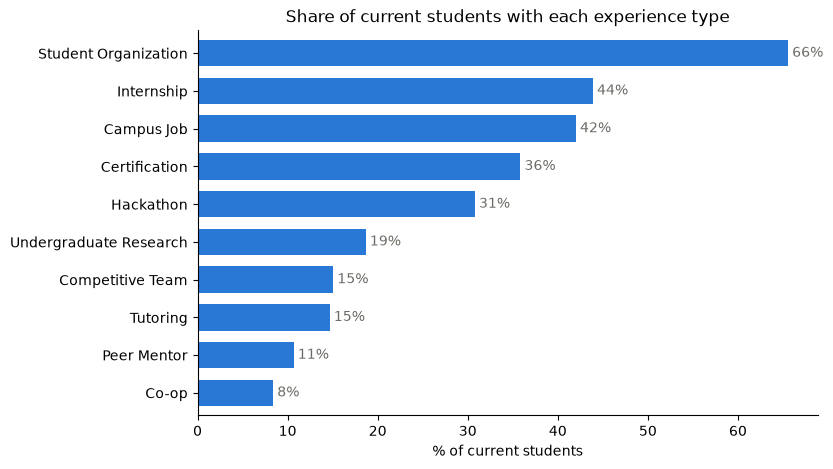

In [510]:
df_expcurr = df_studexp[df_studexp["campus_id"].isin(df_studcurr["campus_id"])]
pct_curr = df_expcurr.groupby("experience_type")["campus_id"].nunique() / len(df_studcurr) * 100

ax = pct_curr.sort_values().plot.barh(color=SERIES_COLORS[0], figsize=(8, 5), width=0.7)
ax.bar_label(ax.containers[0], fmt="%.0f%%", padding=3, color=INK_MUTED)
ax.set(xlabel="% of current students", ylabel="", title="Share of current students with each experience type")
ax.spines[["top", "right"]].set_visible(False)
plt.show()

This chart shows how many current students have done each type of experience. Student organizations are by far the most common (66%), followed by internships (44%) and campus jobs (42%). Co-ops (8%), peer mentoring (11%), and tutoring (15%) are the least common. Since the earlier sections showed that internships are tied to higher salaries, faster hiring, and lower unemployment, the fact that over half of current students haven't done one yet shows a clear opportunity. However, some of this is expected since about half of current students are freshmen or sophomores.

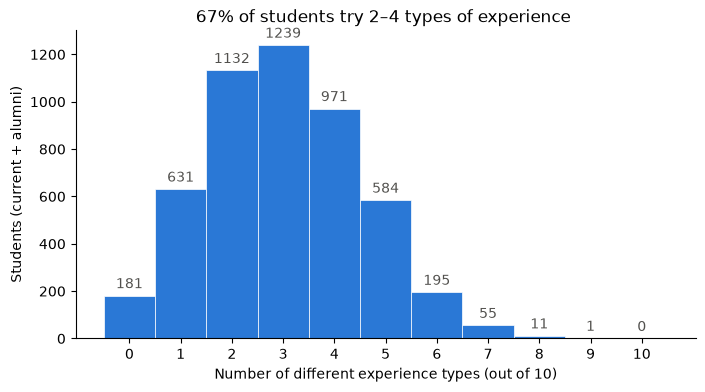

In [ ]:
# Chart: histogram of how many different experience types each person tried (current + alumni)
# breadth = distinct experience types per person; people with no experience rows count as 0
ids = pd.concat([df_studcurr["campus_id"], df_alum["campus_id"]])
breadth = df_studexp.groupby("campus_id")["experience_type"].nunique().reindex(ids, fill_value=0)
share = breadth.between(2, 4).mean() * 100

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(breadth, bins=np.arange(-0.5, 11.5), color=SERIES_COLORS[0], edgecolor="white", linewidth=0.5)
ax.bar_label(ax.containers[0], fmt="%d", padding=3, color=INK_MUTED)
ax.set(xticks=range(11),
       xlabel="Number of different experience types (out of 10)", ylabel="Students (current + alumni)",
       title=f"{share:.0f}% of students try 2–4 types of experience ")
ax.spines[["top", "right"]].set_visible(False)
plt.show()

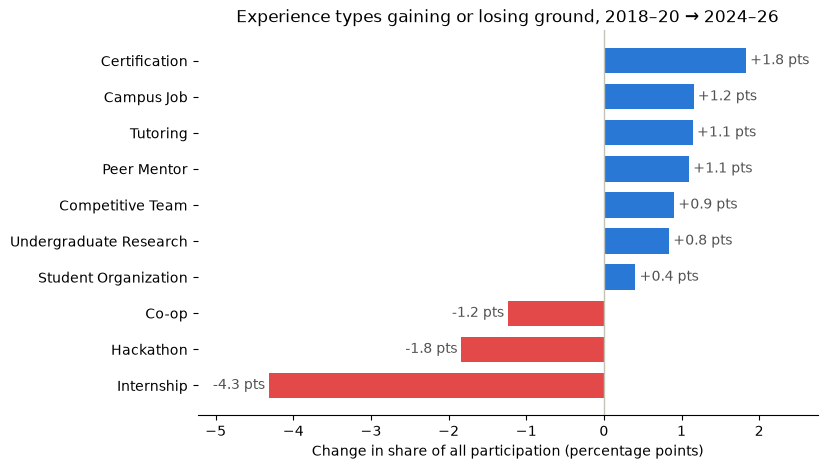

In [ ]:
# Chart: change in each experience type's share of all participation, 2018–20 → 2024–26, diverging bar
# share, not raw counts: current students make recent years busier for every type
year = df_studexp["term"].str[-4:].astype(int)
period = pd.cut(year, [2017, 2020, 2023, 2026], labels=["2018–20", "2021–23", "2024–26"])
typeJoins = pd.DataFrame({"type": df_studexp["experience_type"], "period": period, "campus_id": df_studexp["campus_id"]}).drop_duplicates()
typeShare = pd.crosstab(typeJoins["type"], typeJoins["period"], normalize="columns") * 100
typeChange = (typeShare["2024–26"] - typeShare["2018–20"]).sort_values()

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(typeChange.index, typeChange, color=[SERIES_COLORS[0] if v > 0 else "#e34948" for v in typeChange], height=0.7)
ax.bar_label(ax.containers[0], labels=[f"{v:+.1f} pts" for v in typeChange], padding=3, color=INK_MUTED)
ax.axvline(0, color="#c3c2b7", linewidth=1)
ax.margins(x=0.15)
ax.set(xlabel="Change in share of all participation (percentage points)",
       title="Experience types gaining or losing ground, 2018–20 → 2024–26")
ax.spines[["top", "right", "left"]].set_visible(False)
plt.show()

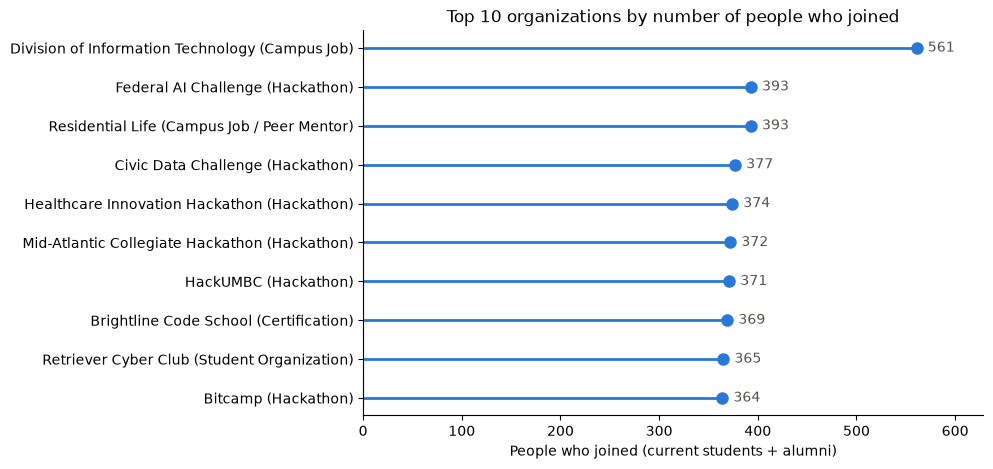

In [ ]:
# Chart: top 10 organizations by number of people who joined (current + alumni), lollipop
# clubs and competitive teams all list organization = "UMBC", so use their activity name instead
org = df_studexp["organization"].where(df_studexp["organization"] != "UMBC", df_studexp["experience_name"])
orgPeople = df_studexp.groupby(org).agg(people=("campus_id", "nunique"),
                                    kind=("experience_type", lambda s: " / ".join(s.unique())))
top10People = orgPeople.nlargest(10, "people")[::-1]   # reversed so #1 is on top
y = [f"{o} ({k})" for o, k in top10People["kind"].items()]

fig, ax = plt.subplots(figsize=(8, 5))
ax.hlines(y, 0, top10People["people"], color=SERIES_COLORS[0], linewidth=2)
ax.scatter(top10People["people"], y, color=SERIES_COLORS[0], s=64, zorder=3)
for yi, v in zip(y, top10People["people"]):
    ax.annotate(f"{v}", (v, yi), xytext=(8, 0), textcoords="offset points", va="center", color=INK_MUTED)
ax.set(xlim=(0, top10People["people"].max() * 1.12), xlabel="People who joined (current students + alumni)",
       title="Top 10 organizations by number of people who joined")
ax.spines[["top", "right"]].set_visible(False)
plt.show()

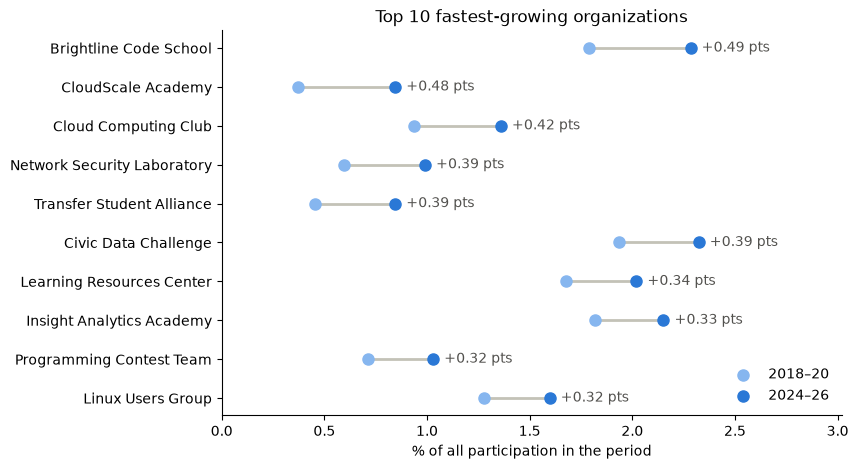

In [ ]:
# Chart: top 10 fastest-growing organizations, dumbbell (share of all participation, 2018–20 vs 2024–26)
# share, not raw counts (see the type growth chart); uses `period` from that chart and `org` from the chart above
joins = pd.DataFrame({"org": org, "period": period, "campus_id": df_studexp["campus_id"]}).drop_duplicates()
share = pd.crosstab(joins["org"], joins["period"], normalize="columns")[["2018–20", "2024–26"]] * 100
share["change"] = share["2024–26"] - share["2018–20"]
top10Grow = share.nlargest(10, "change")[::-1]   # reversed so #1 is on top

fig, ax = plt.subplots(figsize=(8, 5))
ax.hlines(top10Grow.index, top10Grow["2018–20"], top10Grow["2024–26"], color="#c3c2b7", linewidth=2)
ax.scatter(top10Grow["2018–20"], top10Grow.index, color="#86b6ef", s=64, zorder=3, label="2018–20")
ax.scatter(top10Grow["2024–26"], top10Grow.index, color=SERIES_COLORS[0], s=64, zorder=3, label="2024–26")
for o, r in top10Grow.iterrows():
    ax.annotate(f"+{r['change']:.2f} pts", (r["2024–26"], o), xytext=(8, 0), textcoords="offset points",
                va="center", color=INK_MUTED)
ax.set(xlim=(0, top10Grow["2024–26"].max() * 1.3), xlabel="% of all participation in the period",
       title="Top 10 fastest-growing organizations")
ax.legend(loc="lower right", frameon=False)
ax.spines[["top", "right"]].set_visible(False)
plt.show()

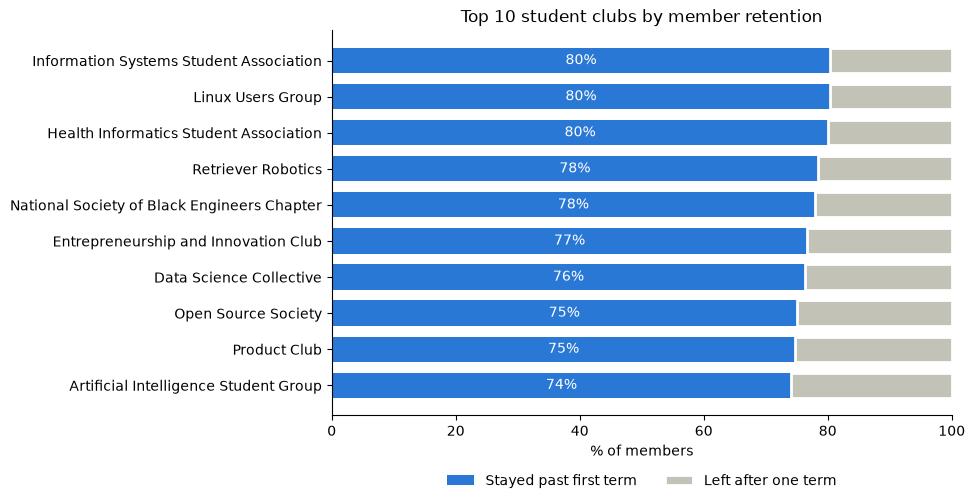

In [ ]:
# Chart: top 10 student clubs by retention = % of members who did not leave after one term, 100% stacked bar
# clubs only: interns stay ~90% vs clubs ~75%, so mixing them would rank only companies; "Active" members count as stayed
clubs = df_studexp[df_studexp["experience_type"] == "Student Organization"]
stayed = (clubs["outcome"] != "Left after one term").groupby(clubs["experience_name"]).mean() * 100
top10Stay = stayed.nlargest(10)[::-1]   # reversed so #1 is on top

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(top10Stay.index, top10Stay, color=SERIES_COLORS[0], height=0.7, label="Stayed past first term")
ax.barh(top10Stay.index, 100 - top10Stay, left=top10Stay, color="#c3c2b7", height=0.7,
        edgecolor="white", linewidth=2, label="Left after one term")
ax.bar_label(ax.containers[0], fmt="%.0f%%", label_type="center", color="white")
ax.set(xlim=(0, 100), xlabel="% of members", title="Top 10 student clubs by member retention")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.12), ncol=2, frameon=False)
ax.spines[["top", "right"]].set_visible(False)
plt.show()

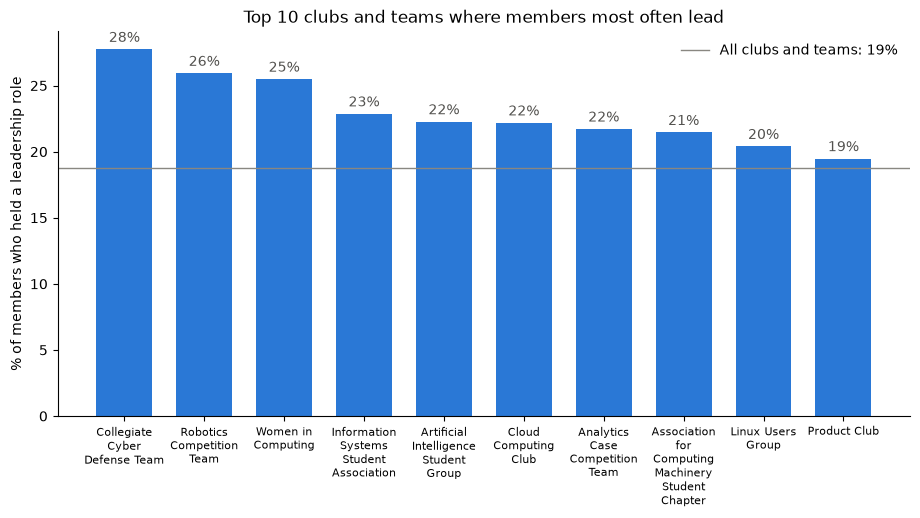

In [ ]:
# Chart: top 10 clubs and competitive teams by leadership rate = % of members who became Officer, President or Lead (column chart)
# clubs and teams only (other activity types have no leadership roles); uses `org` from the headcount chart
import textwrap
groups = df_studexp["experience_type"].isin(["Student Organization", "Competitive Team"])
isLeader = df_studexp.loc[groups, "role_level"].isin(["Officer", "President", "Lead"])
leaderRate = isLeader.groupby(org[groups]).mean() * 100
top10Lead = leaderRate.nlargest(10)

fig, ax = plt.subplots(figsize=(11, 5))
ax.bar([textwrap.fill(o, 12) for o in top10Lead.index], top10Lead, color=SERIES_COLORS[0], width=0.7)
ax.bar_label(ax.containers[0], fmt="%.0f%%", padding=3, color=INK_MUTED)
ax.axhline(isLeader.mean() * 100, color="#898781", linewidth=1, label=f"All clubs and teams: {isLeader.mean():.0%}")
ax.legend(loc="upper right", frameon=False)
ax.tick_params(axis="x", labelsize=8)
ax.set(ylabel="% of members who held a leadership role", title="Top 10 clubs and teams where members most often lead")
ax.spines[["top", "right"]].set_visible(False)
plt.show()

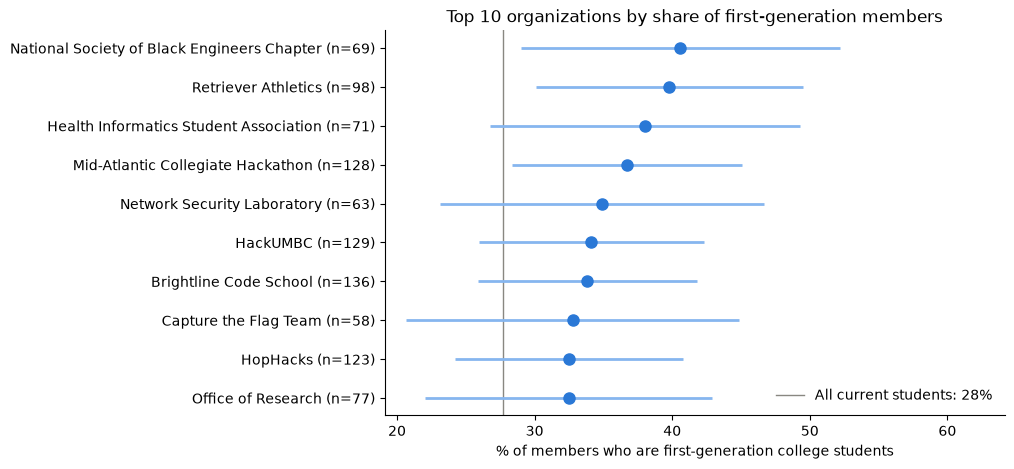

In [ ]:
# Chart: top 10 organizations by share of first-generation members, forest plot with 95% confidence intervals
# current students only (is_first_generation exists only there), orgs with >= 50 current members; uses `org` from the headcount chart
# an interval that crosses the gray campus-wide line means that org's difference could be chance
cur = (df_studexp.assign(org=org)[df_studexp["campus_id"].isin(df_studcurr["campus_id"])]
       .drop_duplicates(["campus_id", "org"])
       .merge(df_studcurr[["campus_id", "is_first_generation"]], on="campus_id"))
firstGenRate = cur.groupby("org")["is_first_generation"].agg(pct="mean", members="size")
firstGenRate["pct"] *= 100
top10Gen = firstGenRate[firstGenRate["members"] >= 50].nlargest(10, "pct")[::-1]   # reversed so #1 is on top
ci = 1.96 * np.sqrt(top10Gen["pct"] * (100 - top10Gen["pct"]) / top10Gen["members"])
campusPct = df_studcurr["is_first_generation"].mean() * 100
y = [f"{o} (n={n})" for o, n in top10Gen["members"].items()]

fig, ax = plt.subplots(figsize=(8, 5))
ax.axvline(campusPct, color="#898781", linewidth=1, label=f"All current students: {campusPct:.0f}%")
ax.errorbar(top10Gen["pct"], y, xerr=ci, fmt="o", color=SERIES_COLORS[0], ecolor="#86b6ef", elinewidth=2, markersize=8)
ax.set_xlim(right=(top10Gen["pct"] + ci).max() + 12)   # room for the legend
ax.legend(loc="lower right", frameon=False)
ax.set(xlabel="% of members who are first-generation college students",
       title="Top 10 organizations by share of first-generation members")
ax.spines[["top", "right"]].set_visible(False)
plt.show()

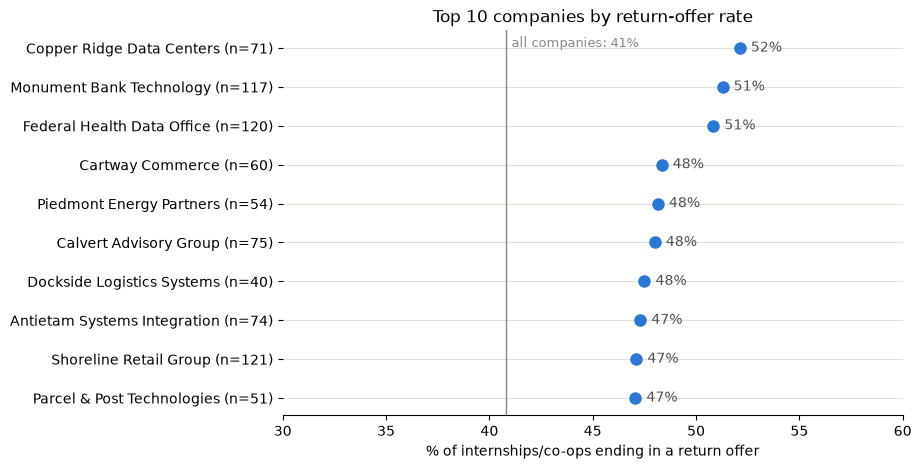

In [ ]:
# Chart: top 10 companies by internship/co-op return-offer rate, dot plot (companies with >= 30 records)
# return offer = "Return offer accepted" or "Return offer declined"; "Converted to part-time role" doesn't count
work = df_studexp[df_studexp["experience_type"].isin(["Internship", "Co-op"])]
gotOffer = work["outcome"].isin(["Return offer accepted", "Return offer declined"])
offerRate = gotOffer.groupby(work["organization"]).agg(["mean", "size"])
top10Offer = offerRate[offerRate["size"] >= 30].nlargest(10, "mean")[::-1]   # reversed so #1 is on top
y = [f"{o} (n={n})" for o, n in top10Offer["size"].items()]
avg = gotOffer.mean() * 100

fig, ax = plt.subplots(figsize=(8, 5))
ax.grid(axis="y", color="#e1e0d9", linewidth=0.8)
ax.set_axisbelow(True)
ax.axvline(avg, color="#898781", linewidth=1)
ax.annotate(f"all companies: {avg:.0f}%", (avg, 1), xycoords=("data", "axes fraction"), xytext=(4, -4),
            textcoords="offset points", va="top", color="#898781", fontsize=9)
ax.scatter(top10Offer["mean"] * 100, y, color=SERIES_COLORS[0], s=64, zorder=3)
for yi, v in zip(y, top10Offer["mean"]):
    ax.annotate(f"{v:.0%}", (v * 100, yi), xytext=(8, 0), textcoords="offset points", va="center", color=INK_MUTED)
ax.set(xlim=(30, 60), xlabel="% of internships/co-ops ending in a return offer",
       title="Top 10 companies by return-offer rate")
ax.spines[["top", "right", "left"]].set_visible(False)
plt.show()

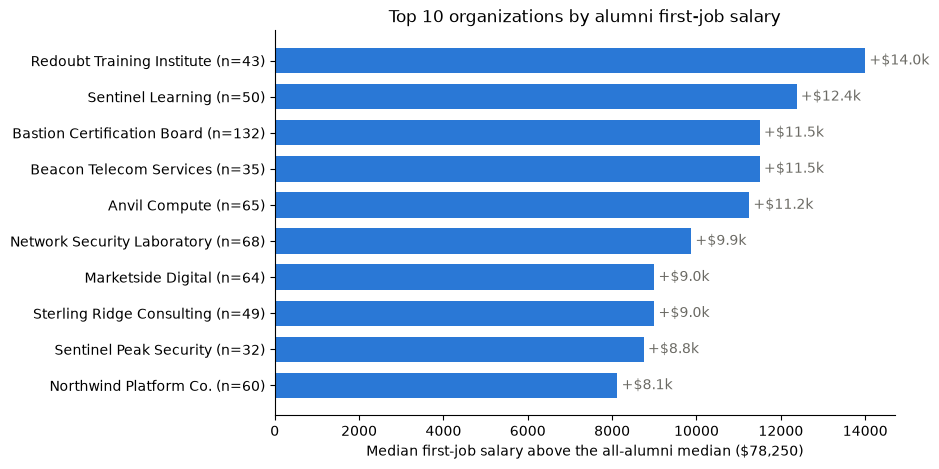

In [511]:
# alumni only; one row per person per organization, so repeat entries don't double-count
df_expalum = df_studexp[df_studexp["campus_id"].isin(df_alum["campus_id"])].drop_duplicates(["campus_id", "organization"])
df_expsalary = df_expalum.merge(df_alum[["campus_id", "first_job_annual_salary_usd"]], on="campus_id")

org_rank = df_expsalary.groupby("organization").agg(
    n=("first_job_annual_salary_usd", "count"),          # alumni with a first-job salary
    median_salary=("first_job_annual_salary_usd", "median"),
)
baseline = df_alum["first_job_annual_salary_usd"].median()
top10 = org_rank[org_rank["n"] >= 30].nlargest(10, "median_salary")
premium = (top10["median_salary"] - baseline)[::-1]   # reversed so #1 is on top

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh([f"{o} (n={n})" for o, n in top10["n"][::-1].items()], premium, color=SERIES_COLORS[0], height=0.7)
ax.bar_label(ax.containers[0], labels=[f"+${v/1000:.1f}k" for v in premium], padding=3, color=INK_MUTED)
ax.set(xlabel=f"Median first-job salary above the all-alumni median (${baseline:,.0f})",
       title="Top 10 organizations by alumni first-job salary")
ax.spines[["top", "right"]].set_visible(False)
plt.show()

This chart ranks organizations (with at least 30 alumni) by the median first-job salary of alumni who were involved with them, compared to the all-alumni median of $78,250. All of the top 10 are between $8K and $14K above the median. 3 of the top 4 are certification providers (Redoubt Training Institute, Sentinel Learning, and Bastion Certification Board), and most of the rest are internship employers in industries that also paid well in the first job section, like Cloud & Infrastructure (Anvil Compute), Telecommunications (Beacon Telecom Services), and Cybersecurity Services (Sentinel Peak Security). This lines up with the job family findings, where Cybersecurity had the highest starting salary. One thing to note is that this shows correlation, not causation: students who pursue these certifications and internships may already be heading toward higher-paying fields.

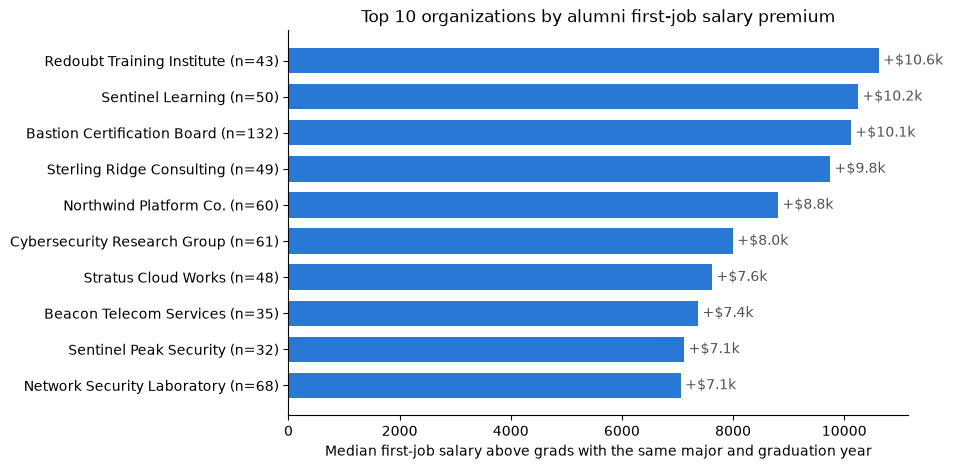

In [ ]:
# Chart: the same top 10 ranking, but against grads with the same major and graduation year instead of all alumni
# alumni only; one row per person per organization, so repeat entries don't double-count
# sal_adj = first-job salary minus the median of grads with the same major and graduation year
sal = df_alum["first_job_annual_salary_usd"]
df_alum["sal_adj"] = sal - sal.groupby([df_alum["major"], df_alum["graduation_year"]]).transform("median")
expAlum = df_studexp[df_studexp["campus_id"].isin(df_alum["campus_id"])].drop_duplicates(["campus_id", "organization"])
m = expAlum.merge(df_alum[["campus_id", "sal_adj"]], on="campus_id")

orgRank = m.groupby("organization").agg(
    n=("sal_adj", "count"),          # alumni with a first-job salary
    premium=("sal_adj", "median"),
)
top10 = orgRank[orgRank["n"] >= 30].nlargest(10, "premium")
plotData = top10[::-1]   # reversed so #1 is on top

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh([f"{o} (n={n})" for o, n in plotData["n"].items()], plotData["premium"], color=SERIES_COLORS[0], height=0.7)
ax.bar_label(ax.containers[0], labels=[f"+${v/1000:.1f}k" for v in plotData["premium"]], padding=3, color=INK_MUTED)
ax.set(xlabel="Median first-job salary above grads with the same major and graduation year",
       title="Top 10 organizations by alumni first-job salary premium")
ax.spines[["top", "right"]].set_visible(False)
plt.show()

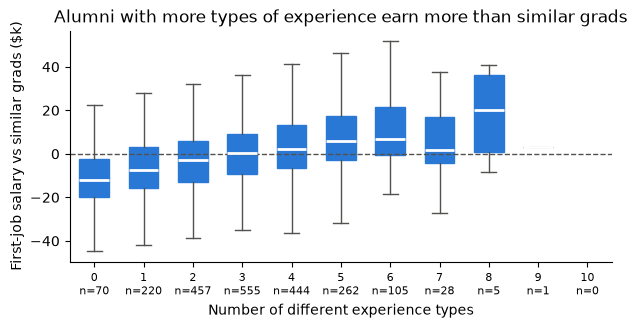

In [ ]:
# Chart: box plot of alumni salary premium by number of experience types tried
# alumni only; salary minus the median of grads with the same major and graduation year (fair comparison across majors and years)
sal = df_alum["first_job_annual_salary_usd"]
adj = (sal - sal.groupby([df_alum["major"], df_alum["graduation_year"]]).transform("median")) / 1000
grp = df_alum["campus_id"].map(breadth)
data = [adj[(grp == k) & adj.notna()] for k in range(11)]
labels = [f"{k}\nn={len(d)}" for k, d in enumerate(data)]

fig, ax = plt.subplots(figsize=(7, 3))
ax.boxplot(data, tick_labels=labels, widths=0.6, showfliers=False, patch_artist=True,
           boxprops=dict(facecolor=SERIES_COLORS[0], edgecolor=SERIES_COLORS[0]), medianprops=dict(color="white", linewidth=2),
           whiskerprops=dict(color=INK_MUTED), capprops=dict(color=INK_MUTED))
ax.axhline(0, color=INK_MUTED, linestyle="--", linewidth=1)
ax.tick_params(axis="x", labelsize=8)
ax.set(xlabel="Number of different experience types", ylabel="First-job salary vs similar grads ($k)",
       title="Alumni with more types of experience earn more than similar grads")
ax.spines[["top", "right"]].set_visible(False)
plt.show()

### Tiger Data

In [ ]:
# data source: Tiger Data (TimescaleDB on Tiger Cloud); tables are loaded by tiger/load_tiger.py and keep the CSV names and columns
# this section needs TIGER_URL in .env; everything above runs from the local CSVs
from dotenv import load_dotenv
from sqlalchemy import create_engine, text

load_dotenv()
tigerUrl = os.getenv("TIGER_URL")
assert tigerUrl, "The Tiger Data section needs TIGER_URL in .env"
engine = create_engine(tigerUrl.replace("postgres://", "postgresql+psycopg://", 1))

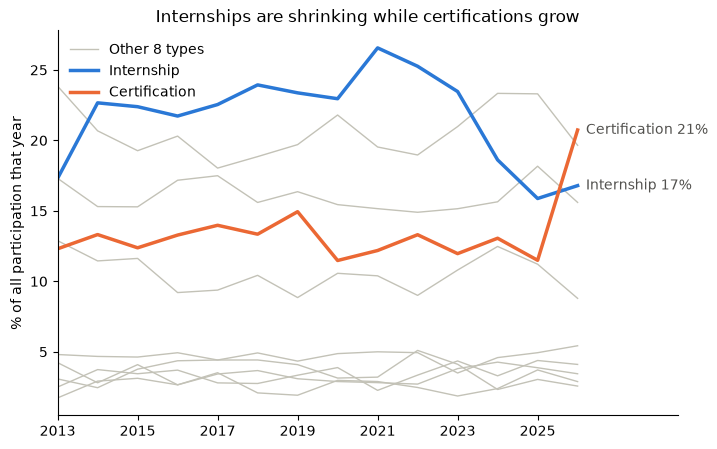

In [ ]:
# Chart: share of all participation by experience type per year, from the continuous aggregate experience_yearly (line chart)
# the aggregate is pre-computed inside Tiger Data, so this reads a few hundred summary rows instead of every activity row
yearly = pd.read_sql("""
    SELECT extract(year FROM year)::int AS year, experience_type, sum(records) AS records
    FROM experience_yearly WHERE year >= '2013-01-01'
    GROUP BY 1, 2""", engine)
shareByYear = yearly.pivot(index="year", columns="experience_type", values="records")
shareByYear = shareByYear.div(shareByYear.sum(axis=1), axis=0) * 100
highlight = {"Internship": SERIES_COLORS[0], "Certification": "#eb6834"}

fig, ax = plt.subplots(figsize=(8, 5))
for i, t in enumerate(shareByYear.columns.drop(list(highlight))):
    ax.plot(shareByYear.index, shareByYear[t], color="#c3c2b7", linewidth=1, label="Other 8 types" if i == 0 else None)
for t, color in highlight.items():
    ax.plot(shareByYear.index, shareByYear[t], color=color, linewidth=2.5, label=t)
    ax.annotate(f"{t} {shareByYear[t].iloc[-1]:.0f}%", (shareByYear.index[-1], shareByYear[t].iloc[-1]),
                xytext=(6, 0), textcoords="offset points", va="center", color=INK_MUTED)
ax.set(xlim=(shareByYear.index[0], shareByYear.index[-1] + 2.5), xticks=shareByYear.index[::2],
       ylabel="% of all participation that year", title="Internships are shrinking while certifications grow")
ax.legend(loc="upper left", frameon=False)
ax.spines[["top", "right"]].set_visible(False)
plt.show()

In [ ]:
# Table: Tiger Data storage: hypertables, chunks and columnstore compression
# profiles (students_current, alumni, course_catalog) are plain Postgres tables; activity streams are hypertables
pd.read_sql("""
    SELECT h.hypertable_name AS "table", h.num_chunks AS chunks,
           pg_size_pretty(s.before) AS "row store", pg_size_pretty(s.after) AS columnstore,
           round(100 * (1 - s.after::numeric / s.before))::int AS saved_pct
    FROM timescaledb_information.hypertables h,
         LATERAL (SELECT sum(before_compression_total_bytes)::bigint AS before,
                         sum(after_compression_total_bytes)::bigint AS after
                  FROM chunk_columnstore_stats((h.hypertable_schema || '.' || h.hypertable_name)::regclass)) s
    ORDER BY s.before DESC""", engine)

,table,chunks,row store,columnstore,saved_pct
0,transcripts,5,29 MB,2624 kB,91
1,student_experience,5,5320 kB,904 kB,83
2,employment_history,3,3496 kB,624 kB,82


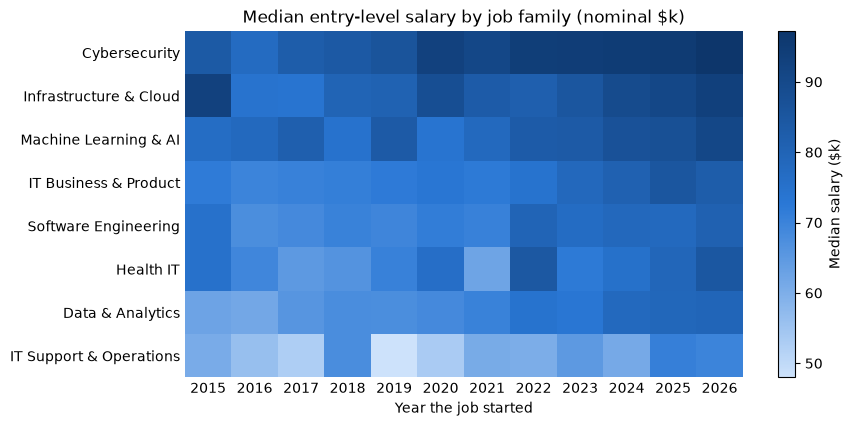

In [ ]:
# Chart: median entry-level salary by job family and start year, from the continuous aggregate salary_by_year (heatmap)
# percentile_agg sketches (timescaledb_toolkit) merge with rollup(), so medians come straight from the aggregate
entry = pd.read_sql("""
    SELECT extract(year FROM year)::int AS year, job_family,
           approx_percentile(0.5, rollup(salary_pct)) / 1000 AS median_k
    FROM salary_by_year WHERE seniority_level = 'Entry'
    GROUP BY 1, 2""", engine).pivot(index="job_family", columns="year", values="median_k")
entry = entry.loc[entry.mean(axis=1).sort_values(ascending=False).index]   # highest-paid family on top
blues = matplotlib.colors.LinearSegmentedColormap.from_list("blues", ["#cde2fb", SERIES_COLORS[0], "#0d366b"])

fig, ax = plt.subplots(figsize=(9, 4.5))
im = ax.imshow(entry, cmap=blues, aspect="auto")
ax.set(xticks=range(len(entry.columns)), xticklabels=entry.columns, yticks=range(len(entry)), yticklabels=entry.index,
       xlabel="Year the job started", title="Median entry-level salary by job family (nominal $k)")
fig.colorbar(im, ax=ax, label="Median salary ($k)")
ax.tick_params(length=0)
ax.spines[:].set_visible(False)
plt.show()

In [ ]:
# Table: benchmark, the same question answered from the raw hypertable vs the continuous aggregate
# server-side execution time from EXPLAIN ANALYZE (median of 5 runs), so network latency doesn't blur the comparison
queries = {
    "raw hypertable: transcripts": """SELECT time_bucket('1 month', term_start) AS term, subject, avg(grade_points) AS avg_grade_points
                                      FROM transcripts GROUP BY 1, 2""",
    "continuous aggregate: grades_by_term": "SELECT term, subject, avg_grade_points FROM grades_by_term",
}

def serverMs(sql, runs=5):
    with engine.connect() as c:
        return np.median([c.execute(text("EXPLAIN (ANALYZE, FORMAT JSON) " + sql)).scalar()[0]["Execution Time"]
                          for _ in range(runs)])

rawRes, aggRes = (pd.read_sql(q, engine).sort_values(["term", "subject"], ignore_index=True) for q in queries.values())
assert np.allclose(rawRes["avg_grade_points"], aggRes["avg_grade_points"], equal_nan=True)   # same answer, pre-computed

bench = pd.DataFrame({"rows returned": [len(rawRes), len(aggRes)],
                      "server time (ms)": [round(serverMs(q), 2) for q in queries.values()]}, index=list(queries))
bench["speed-up"] = (bench["server time (ms)"].iloc[0] / bench["server time (ms)"]).round().astype(int).astype(str) + "x"
bench

,rows returned,server time (ms),speed-up
raw hypertable: transcripts,818,14.29,1x
continuous aggregate: grades_by_term,818,0.20,71x
